## What is the most optimal skill to learn for Data Analyst?

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import locale
import ast
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')  # Força locale para inglês

#Getting the data
df = pd.read_csv('data_jobs.csv')

#Cleaning the data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Salary distribution by skills

The US is the country with the most data in this dataset, so i'm gonna filter by it.

In [26]:
#Getting Data Analyst Jobs from the US
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_US.dropna(subset='salary_year_avg',inplace=True)
df_DA_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
180,Data Analyst,Data Analyst III,"Dos Palos, CA",via My ArkLaMiss Jobs,Full-time,False,"California, United States",2023-02-27 13:00:39,False,True,United States,year,90250.0,NaN,California Health & Wellness,"[excel, powerpoint]","{'analyst_tools': ['excel', 'powerpoint']}"
410,Data Analyst,IT Business Lead Data Analyst - VP - Hybrid,"Atlantic Beach, FL",via ComputerJobs.com,Full-time,False,Georgia,2023-01-10 13:59:02,False,False,United States,year,133285.0,NaN,Citi,"[sql, word, excel, visio, powerpoint, sharepoint]","{'analyst_tools': ['word', 'excel', 'visio', '..."
988,Data Analyst,DATA ANALYST (ONSITE),"Springfield, MA",via Indeed,Full-time,False,"New York, United States",2023-11-21 13:00:13,False,False,United States,year,62623.0,NaN,Springfield Public Schools,"[sql, excel, tableau]","{'analyst_tools': ['excel', 'tableau'], 'progr..."
1413,Data Analyst,Junior BI Developer,"Atlanta, GA",via Ai-Jobs.net,Full-time,False,Georgia,2023-10-31 13:57:41,False,True,United States,year,71300.0,NaN,Guidehouse,"[sql, excel, power bi]","{'analyst_tools': ['excel', 'power bi'], 'prog..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782637,Data Analyst,Data Integration Analyst,"Germantown, WI",via ZipRecruiter,Full-time,False,"Illinois, United States",2023-01-20 06:18:43,True,False,United States,year,70000.0,NaN,Virtual Benefits Administrator,"[vba, sql, sql server]","{'databases': ['sql server'], 'programming': [..."
782798,Data Analyst,Reference Data Analyst,"New York, NY",via Ai-Jobs.net,Full-time,False,"New York, United States",2023-04-21 05:59:51,True,False,United States,year,111175.0,NaN,DRW,[terminal],{'other': ['terminal']}
783588,Data Analyst,Data Analytics Manager,"Chicago, IL",via Ladders,Full-time,False,"Illinois, United States",2023-01-09 06:01:18,False,False,United States,year,125000.0,NaN,"United Air Lines, Inc","[sql, r, python, hadoop, excel]","{'analyst_tools': ['excel'], 'libraries': ['ha..."
783866,Data Analyst,Lead Credit Bureau Data Analyst,"Des Plaines, IL",via Ladders,Full-time,False,"Illinois, United States",2023-06-02 06:02:06,False,True,United States,year,115000.0,NaN,Discover Financial Services,[unix],{'os': ['unix']}


#### Exploding the skills column and getting the percentage

In [27]:
#Exploding the skills and formatting
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values('count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

#Getting the porcentage per skill
DA_job_counts = len(df_DA_US)
df_DA_skills['skill_percent'] = df_DA_skills['skill_count']/DA_job_counts * 100


#Filter for relevant skills
skill_percent = 5

df_DA_skills_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


#### Getting the technology type

In [28]:
#Type of technology
df_technology = df['job_type_skills'].copy()
df_technology.drop_duplicates(inplace=True)
df_technology.dropna(inplace=True)

#Combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row) #Converts string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

#remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))


technology_dict

{'analyst_tools': ['sap',
  'dax',
  'outlook',
  'powerpoint',
  'esquisse',
  'qlik',
  'alteryx',
  'microstrategy',
  'sas',
  'datarobot',
  'ssrs',
  'nuix',
  'sheets',
  'cognos',
  'looker',
  'spreadsheet',
  'excel',
  'sharepoint',
  'visio',
  'spss',
  'word',
  'tableau',
  'ssis',
  'msaccess',
  'powerbi',
  'ms access',
  'power bi',
  'splunk'],
 'programming': ['julia',
  'golang',
  'css',
  'lua',
  'haskell',
  'c++',
  'javascript',
  'vb.net',
  'lisp',
  'no-sql',
  'assembly',
  't-sql',
  'ruby',
  'r',
  'java',
  'scala',
  'solidity',
  'powershell',
  'kotlin',
  'sas',
  'elixir',
  'sql',
  'dart',
  'matlab',
  'typescript',
  'mongodb',
  'erlang',
  'python',
  'crystal',
  'groovy',
  'cobol',
  'html',
  'php',
  'clojure',
  'objective-c',
  'fortran',
  'visual basic',
  'nosql',
  'ocaml',
  'c#',
  'vba',
  'visualbasic',
  'swift',
  'bash',
  'perl',
  'rust',
  'c',
  'sass',
  'apl',
  'go',
  'pascal',
  'shell',
  'f#',
  'mongo',
  'del

In [29]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,sap
0,analyst_tools,dax
0,analyst_tools,outlook
0,analyst_tools,powerpoint
0,analyst_tools,esquisse
...,...,...
9,sync,ringcentral
9,sync,wire
9,sync,twilio
9,sync,slack


### Visualizing the optimal skills

In [30]:
df_plot = df_DA_skills_demand.merge(df_technology, left_on='job_skills', right_on='skills')


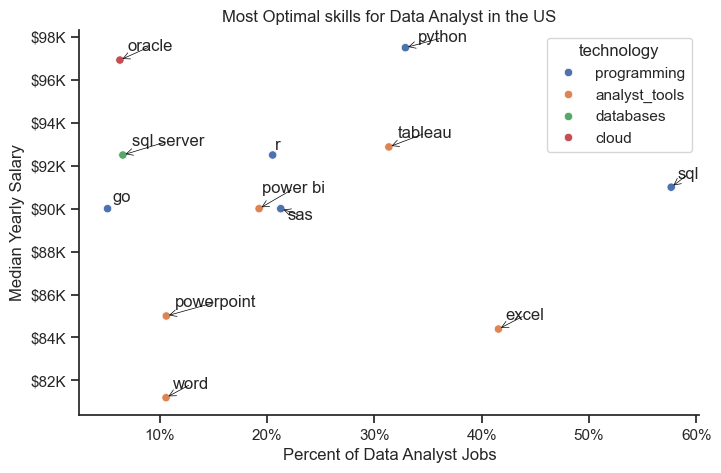

In [31]:
from adjustText import adjust_text

sns.set_theme(style='ticks')
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_plot,
                x='skill_percent',
                y='median_salary',
                hue='technology')

sns.despine()


ax = plt.gca() #get current access
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'${int(y/1000)}K')) #y é o valor, pos é o indice
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{x:.0f}%')) #y é o valor, pos é o indice

#Prepare texts for adjust_text
texts=[]
for i,txt in enumerate(df_DA_skills_demand.index):
    texts.append(plt.text(x=df_DA_skills_demand['skill_percent'].iloc[i],
                          y=df_DA_skills_demand['median_salary'].iloc[i],
                          s=txt))

#Adjust text to avoid overlap
adjust_text(
    texts,
    expand=(1.5, 1.8),           # aumenta a "bolha" de repulsão ao redor de cada texto
    force_text=(0.8, 1.0),       # força de repulsão entre textos
    force_points=(0.5, 0.8),     # força de repulsão entre texto e ponto
    arrowprops=dict(arrowstyle='->', color='black', lw=0.5)
)


plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal skills for Data Analyst in the US')
plt.show()

#### Visualizing the correlation

We can see that we don't have a correlation between demand and salary.

In [40]:
# Normalizing demand frequency and median salary to test correlation
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = df_plot[['median_salary', 'skill_count']].copy()
df_normalized[['median_salary', 'skill_count']] = scaler.fit_transform(
    df_normalized[['median_salary', 'skill_count']]
)

df_normalized['median_salary'].corr(df_normalized['skill_count'])
# Result: no significant correlation between demand and pay

np.float64(0.047554932176720445)

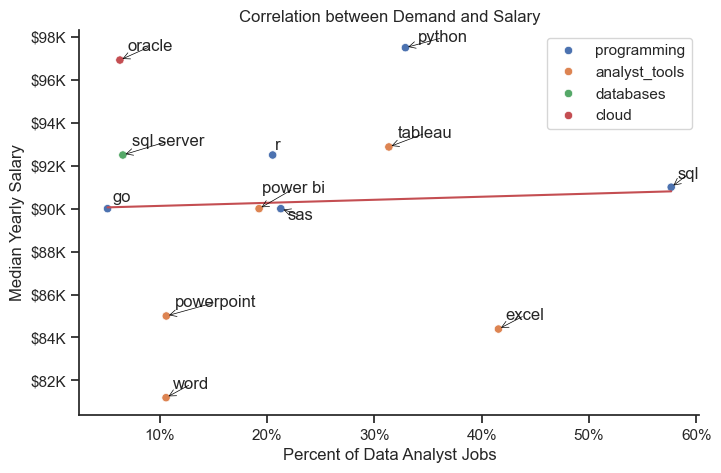

In [32]:
from scipy import stats


df_regression = df_plot.copy()

m, b, r, p, se = stats.linregress(df_regression['skill_percent'], df_regression['median_salary'])


df_regression['fx'] = (m * df_regression['skill_percent']) + b

df_regression['error'] = df_regression['fx'] - df_regression['median_salary']


sns.set_theme(style='ticks')
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_regression,
                x='skill_percent',
                y='median_salary',
                hue='technology')

sns.lineplot(data=df_regression, x='skill_percent', y='fx', color= 'r')
sns.despine()


ax = plt.gca() #get current access
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'${int(y/1000)}K')) #y é o valor, pos é o indice
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{x:.0f}%')) #y é o valor, pos é o indice

#Prepare texts for adjust_text
texts=[]
for i,txt in enumerate(df_DA_skills_demand.index):
    texts.append(plt.text(x=df_DA_skills_demand['skill_percent'].iloc[i],
                          y=df_DA_skills_demand['median_salary'].iloc[i],
                          s=txt))

#Adjust text to avoid overlap
adjust_text(
    texts,
    expand=(1.5, 1.8),           # aumenta a "bolha" de repulsão ao redor de cada texto
    force_text=(0.8, 1.0),       # força de repulsão entre textos
    force_points=(0.5, 0.8),     # força de repulsão entre texto e ponto
    arrowprops=dict(arrowstyle='->', color='black', lw=0.5)
)


plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Correlation between Demand and Salary')
plt.show()